In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

print("Setup Successful 🚀")


Setup Successful 🚀


In [4]:
df = pd.read_csv('stud.csv')


In [5]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
df.shape

(1000, 8)

In [7]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [9]:
print("Categories in 'race/ethnicity' variable:  ",end=" ")
print(df['race/ethnicity'].unique())

# You will also need to do this for the other columns with spaces:
print("Categories in 'parental level of education' variable:",end=" " )
print(df['parental level of education'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test preparation course'].unique())

Categories in 'race/ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [10]:
# Load the data
df = pd.read_csv('stud.csv')

# Replace spaces and slashes with underscores in all column names
df.columns = df.columns.str.replace(' ', '_').str.replace('/', '_')

# Now your code from the third screenshot will work perfectly!
print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']


In [11]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']

We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [12]:
df['total score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [13]:
reading_full = df[df['reading_score'] == 100]['average'].count()
writing_full = df[df['writing_score'] == 100]['average'].count()
math_full = df[df['math_score'] == 100]['average'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [14]:
reading_less_20 = df[df['reading_score'] <= 20]['average'].count()
writing_less_20 = df[df['writing_score'] <= 20]['average'].count()
math_less_20 = df[df['math_score'] <= 20]['average'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


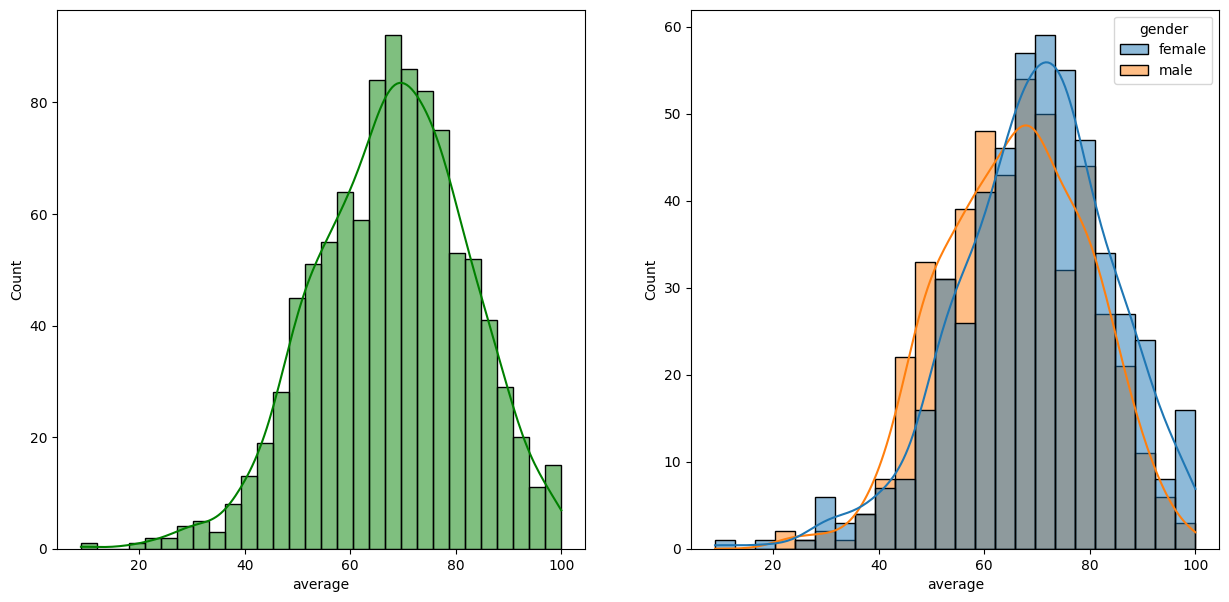

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df, x='average', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='average', kde=True, hue='gender')
plt.show()

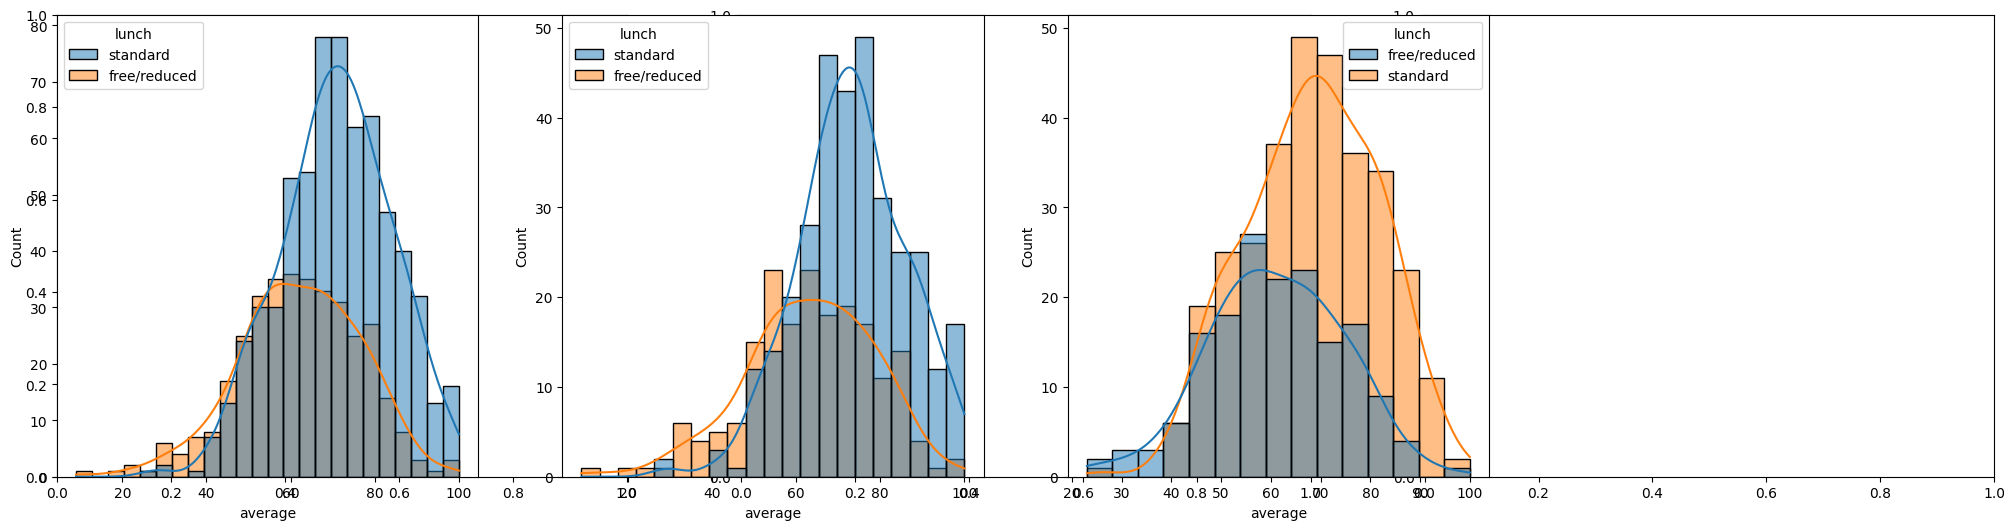

In [16]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='lunch')
plt.show()

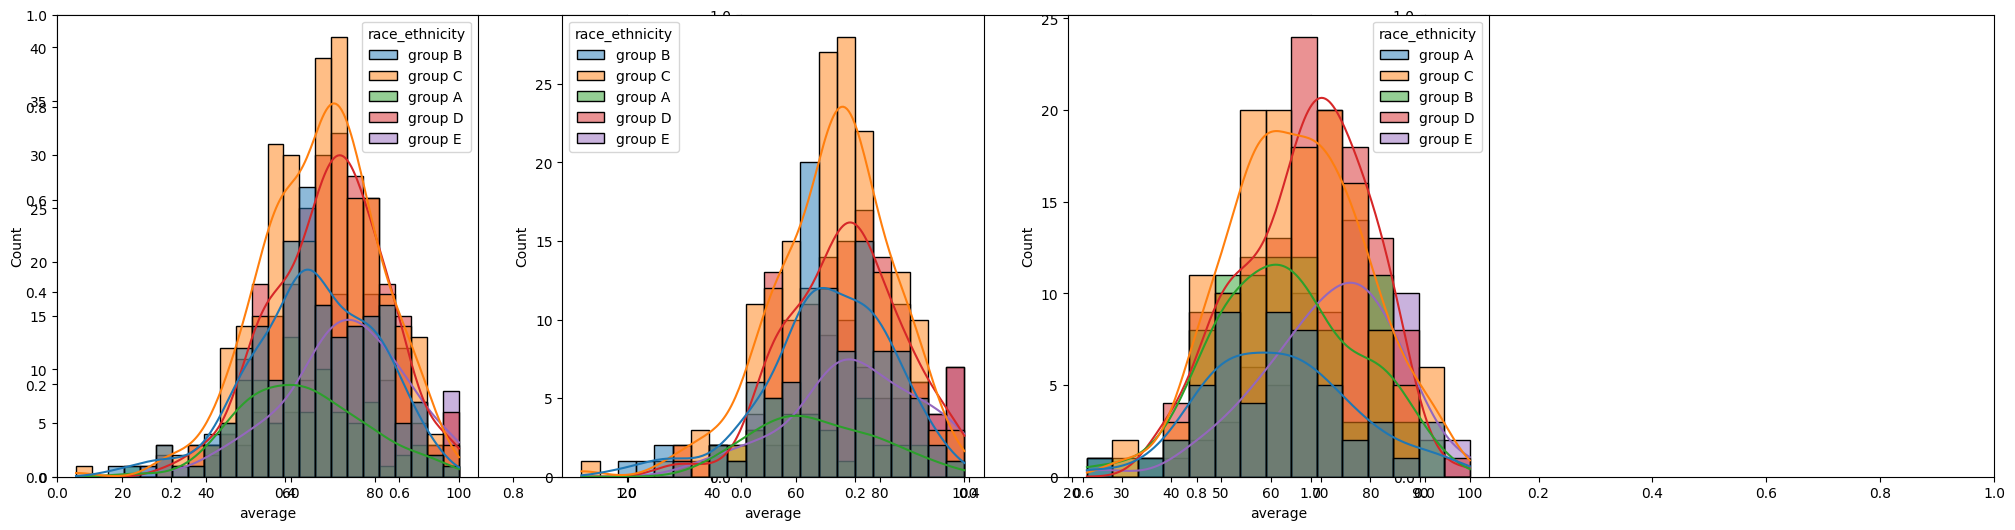

In [18]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='average',kde=True,hue='race_ethnicity')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='race_ethnicity')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='race_ethnicity')
plt.show()

In [24]:
print(df.columns.tolist())

['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score', 'total score', 'average']


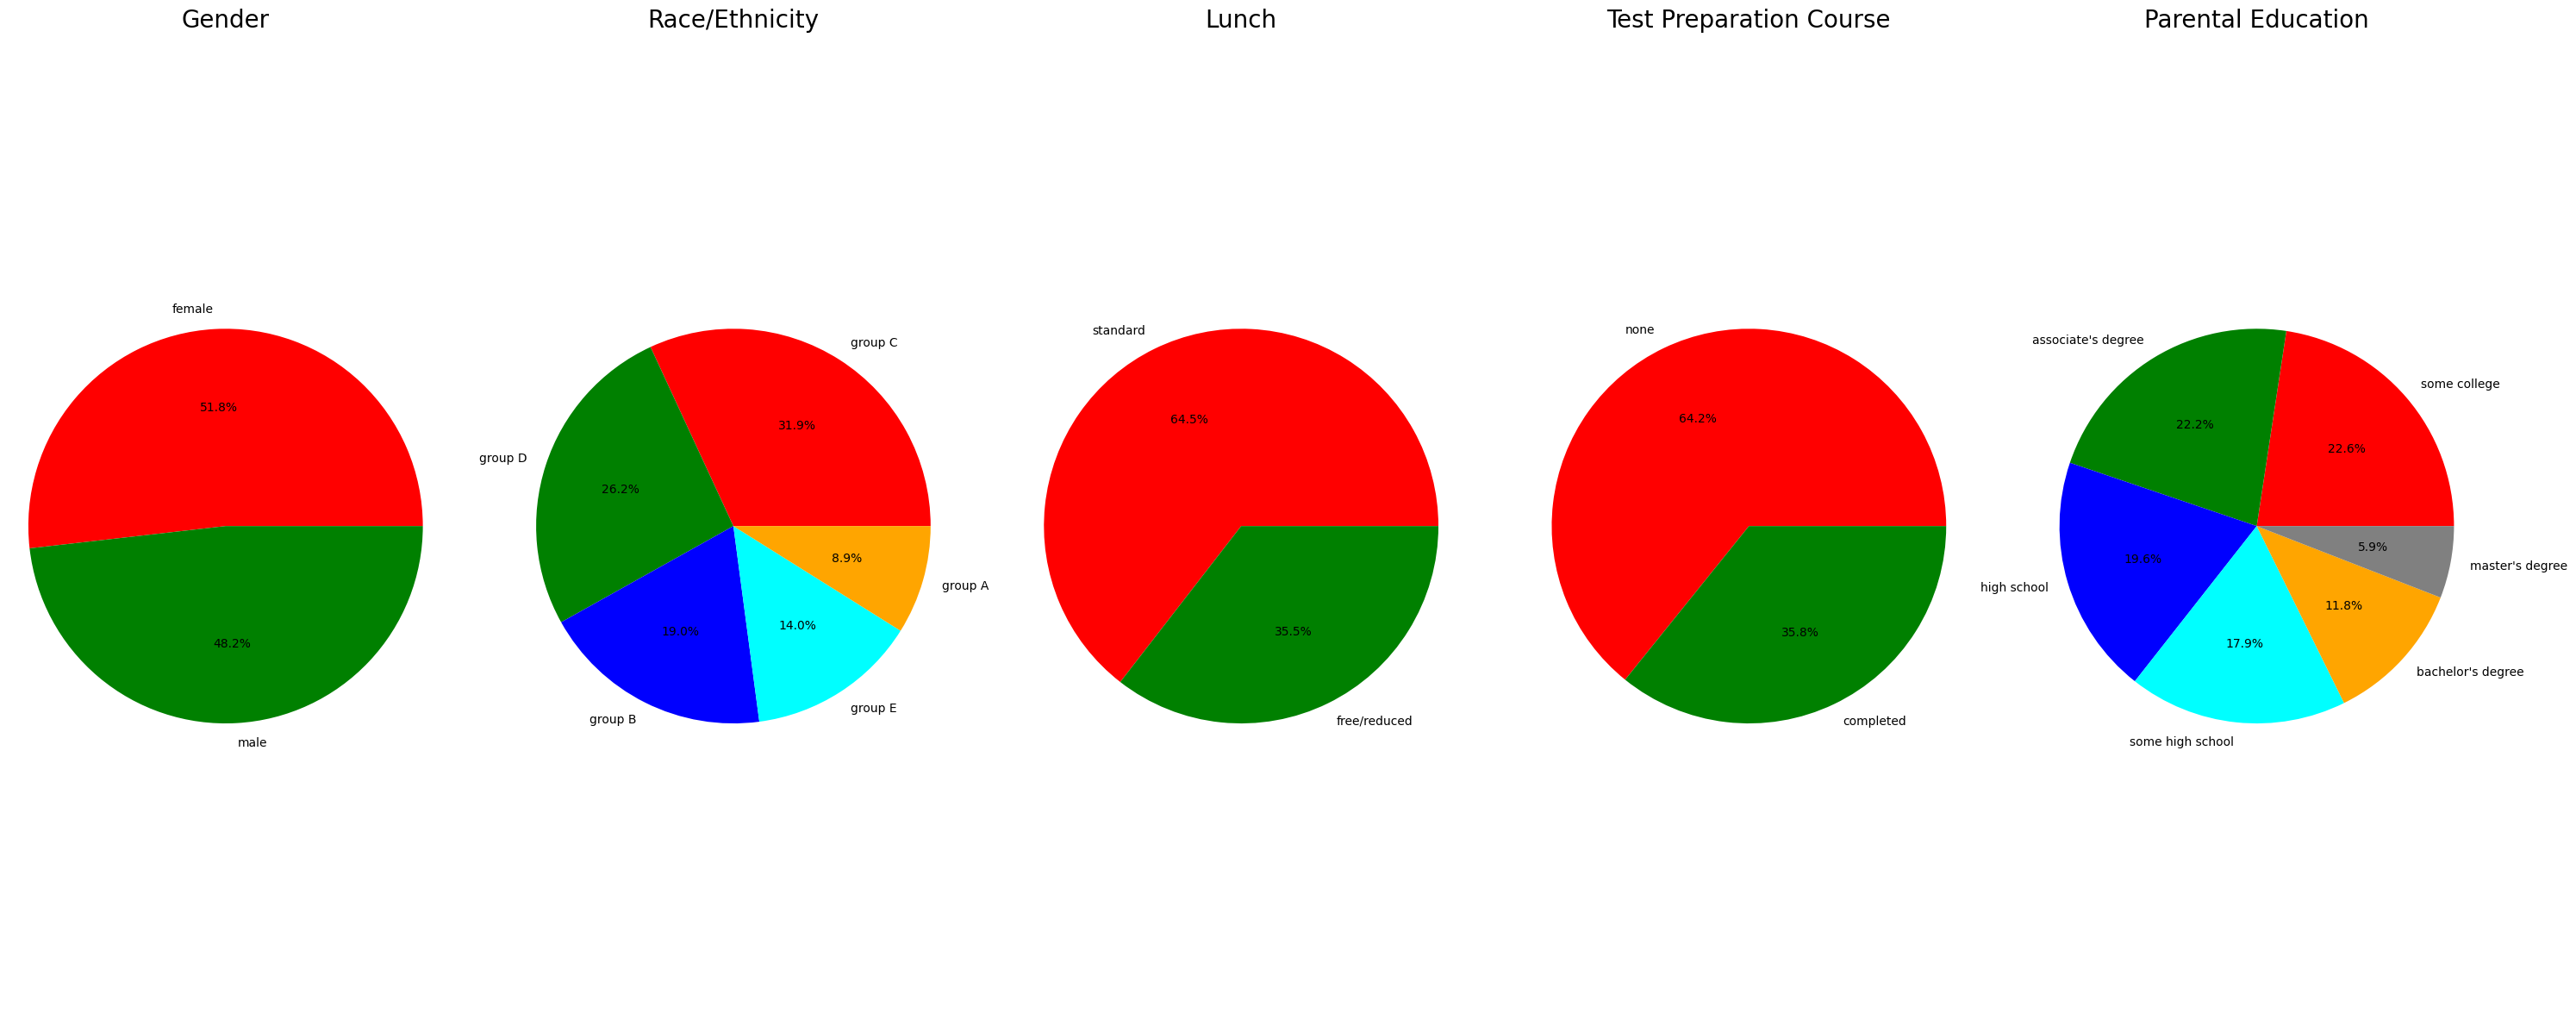

In [25]:
plt.rcParams['figure.figsize'] = (30, 12)

# Gender
plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
plt.pie(
    size,
    labels=size.index,
    colors=['red', 'green'],
    autopct='%1.1f%%'
)
plt.title('Gender', fontsize=20)
plt.axis('equal')

# Race/Ethnicity
plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
plt.pie(
    size,
    labels=size.index,
    colors=['red', 'green', 'blue', 'cyan', 'orange'],
    autopct='%1.1f%%'
)
plt.title('Race/Ethnicity', fontsize=20)
plt.axis('equal')

# Lunch
plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
plt.pie(
    size,
    labels=size.index,
    colors=['red', 'green'],
    autopct='%1.1f%%'
)
plt.title('Lunch', fontsize=20)
plt.axis('equal')

# Test Preparation Course
plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
plt.pie(
    size,
    labels=size.index,
    colors=['red', 'green'],
    autopct='%1.1f%%'
)
plt.title('Test Preparation Course', fontsize=20)
plt.axis('equal')

# Parental Education
plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
plt.pie(
    size,
    labels=size.index,
    colors=['red', 'green', 'blue', 'cyan', 'orange', 'grey'],
    autopct='%1.1f%%'
)
plt.title('Parental Education', fontsize=20)
plt.axis('equal')

plt.tight_layout()
plt.show()

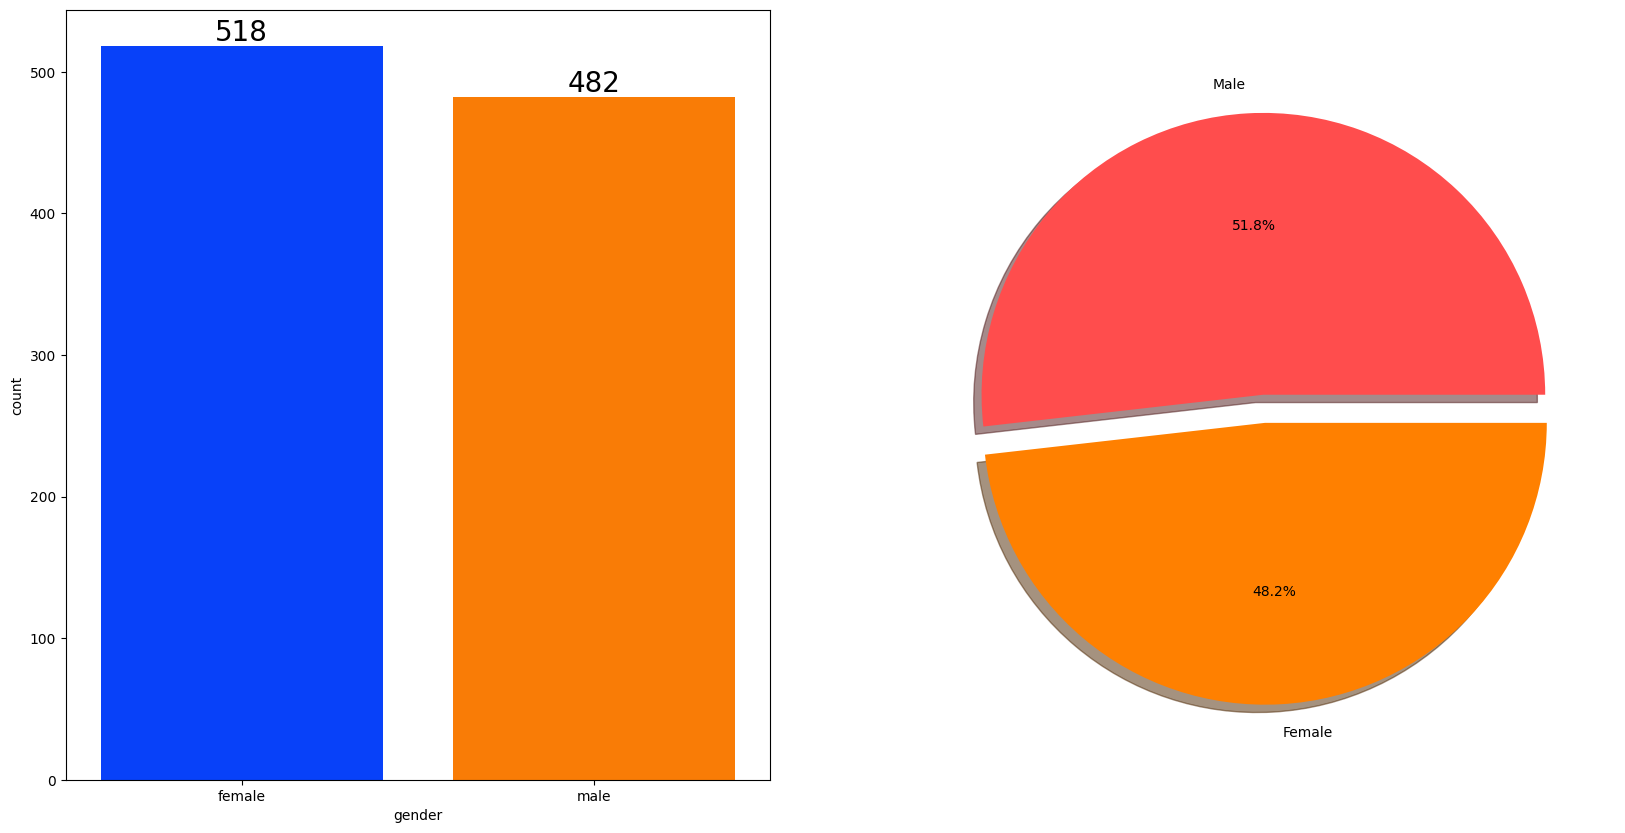

In [26]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

In [29]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math_score,reading_score,writing_score,total score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


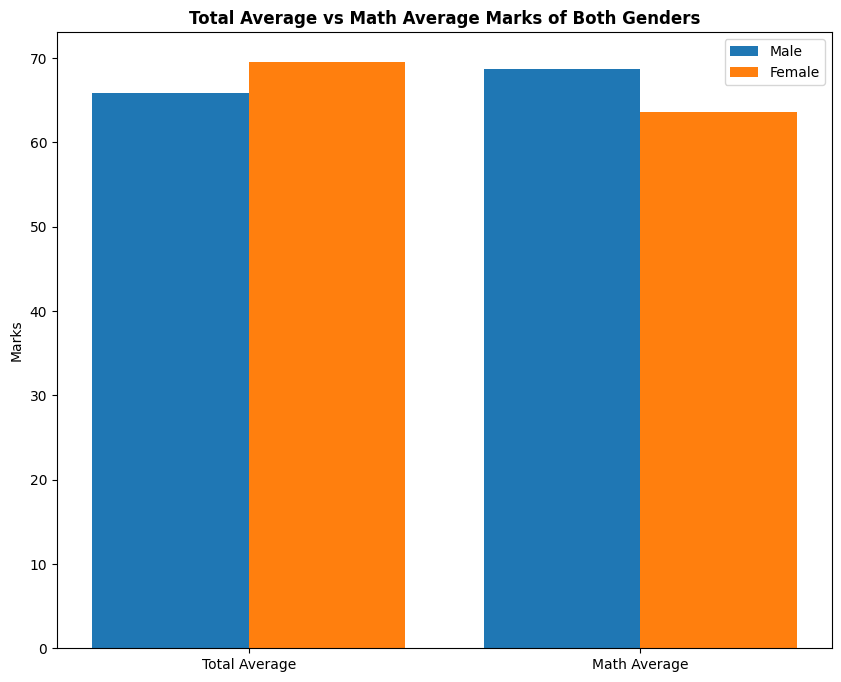

In [32]:
plt.figure(figsize=(10, 8))

X = ['Total Average', 'Math Average']

female_scores = [
    gender_group.loc['female', 'average'],
    gender_group.loc['female', 'math_score']
]

male_scores = [
    gender_group.loc['male', 'average'],
    gender_group.loc['male', 'math_score']
]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label='Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label='Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total Average vs Math Average Marks of Both Genders", fontweight='bold')
plt.legend()

plt.show()

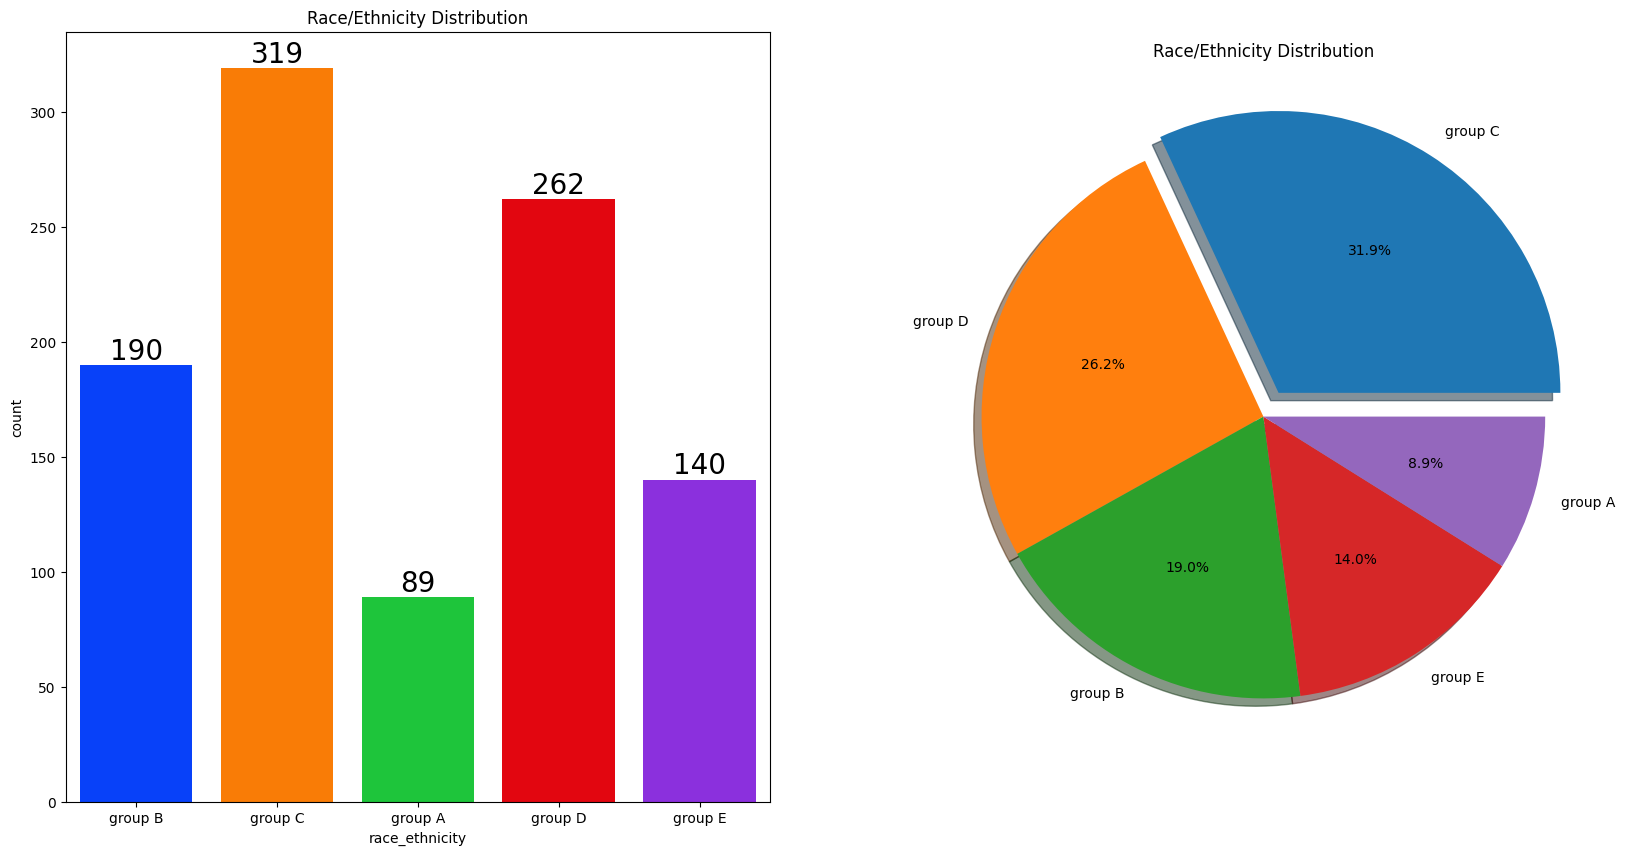

In [33]:
f, ax = plt.subplots(1, 2, figsize=(20, 10))

# Count Plot
sns.countplot(
    x='race_ethnicity',
    data=df,
    palette='bright',
    ax=ax[0],
    saturation=0.95
)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

ax[0].set_title("Race/Ethnicity Distribution")

# Pie Chart
ax[1].pie(
    x=df['race_ethnicity'].value_counts(),
    labels=df['race_ethnicity'].value_counts().index,
    explode=[0.1, 0, 0, 0, 0],
    autopct='%1.1f%%',
    shadow=True
)
ax[1].set_title("Race/Ethnicity Distribution")

plt.show()

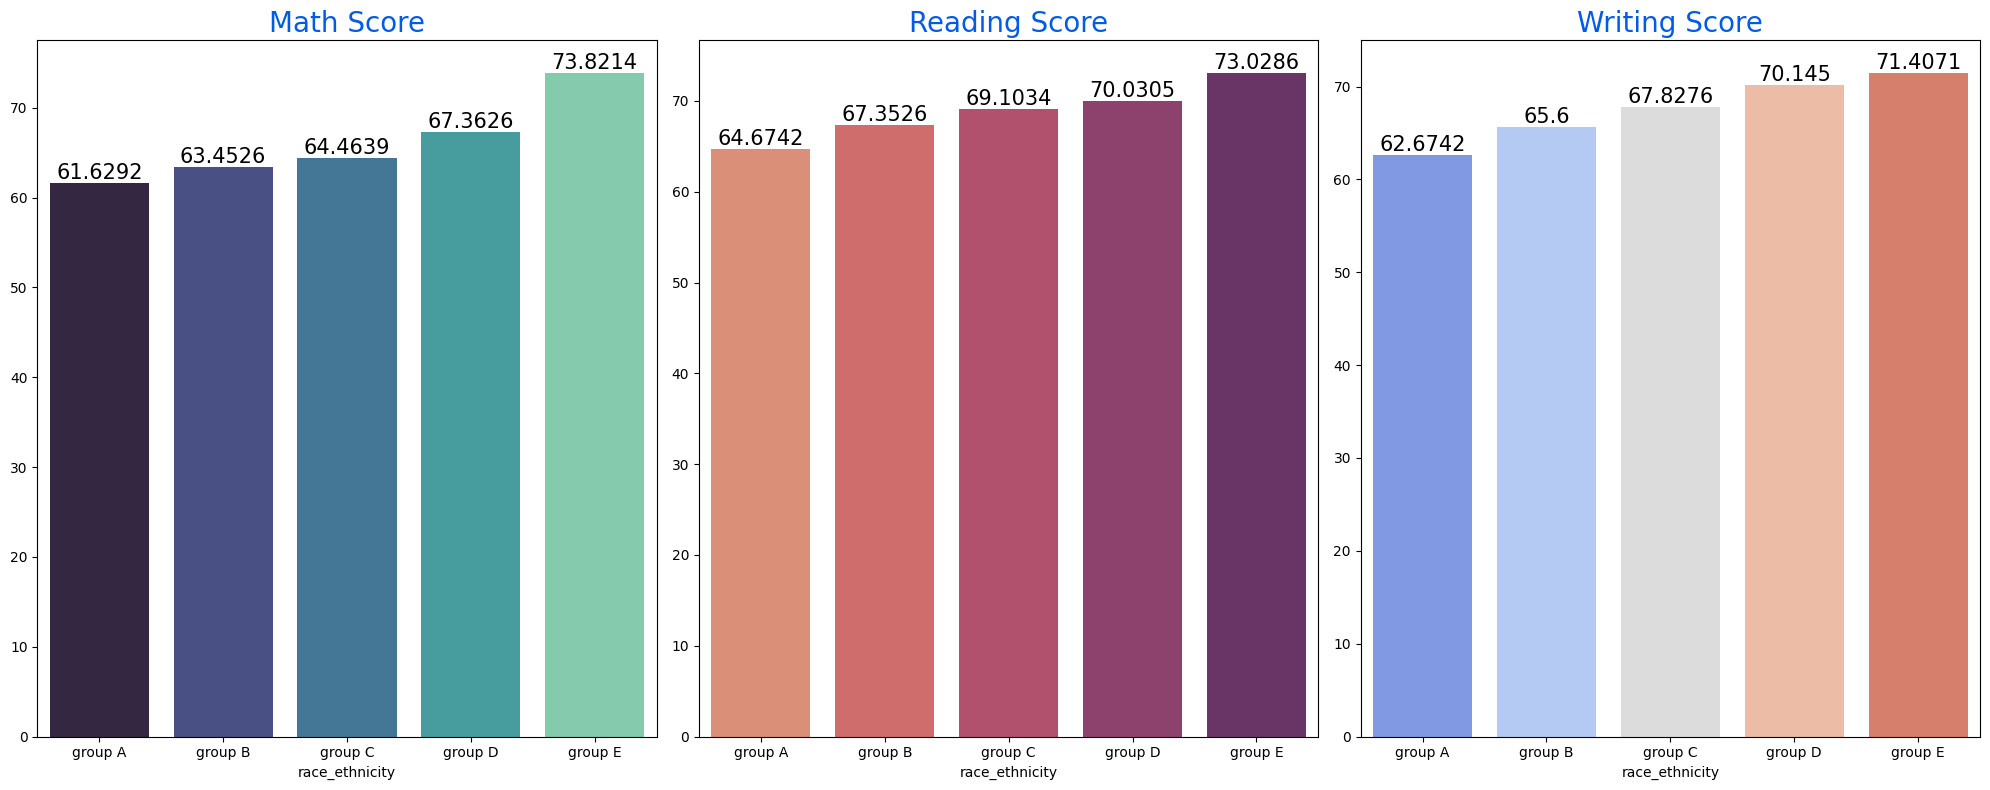

In [35]:
Group_data2 = df.groupby('race_ethnicity')

f, ax = plt.subplots(1, 3, figsize=(20, 8))

# Math Score
sns.barplot(
    x=Group_data2['math_score'].mean().index,
    y=Group_data2['math_score'].mean().values,
    palette='mako',
    ax=ax[0]
)
ax[0].set_title('Math Score', color='#005ce6', size=20)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=15)

# Reading Score
sns.barplot(
    x=Group_data2['reading_score'].mean().index,
    y=Group_data2['reading_score'].mean().values,
    palette='flare',
    ax=ax[1]
)
ax[1].set_title('Reading Score', color='#005ce6', size=20)

for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=15)

# Writing Score
sns.barplot(
    x=Group_data2['writing_score'].mean().index,
    y=Group_data2['writing_score'].mean().values,
    palette='coolwarm',
    ax=ax[2]
)
ax[2].set_title('Writing Score', color='#005ce6', size=20)

for container in ax[2].containers:
    ax[2].bar_label(container, color='black', size=15)

plt.tight_layout()
plt.show()

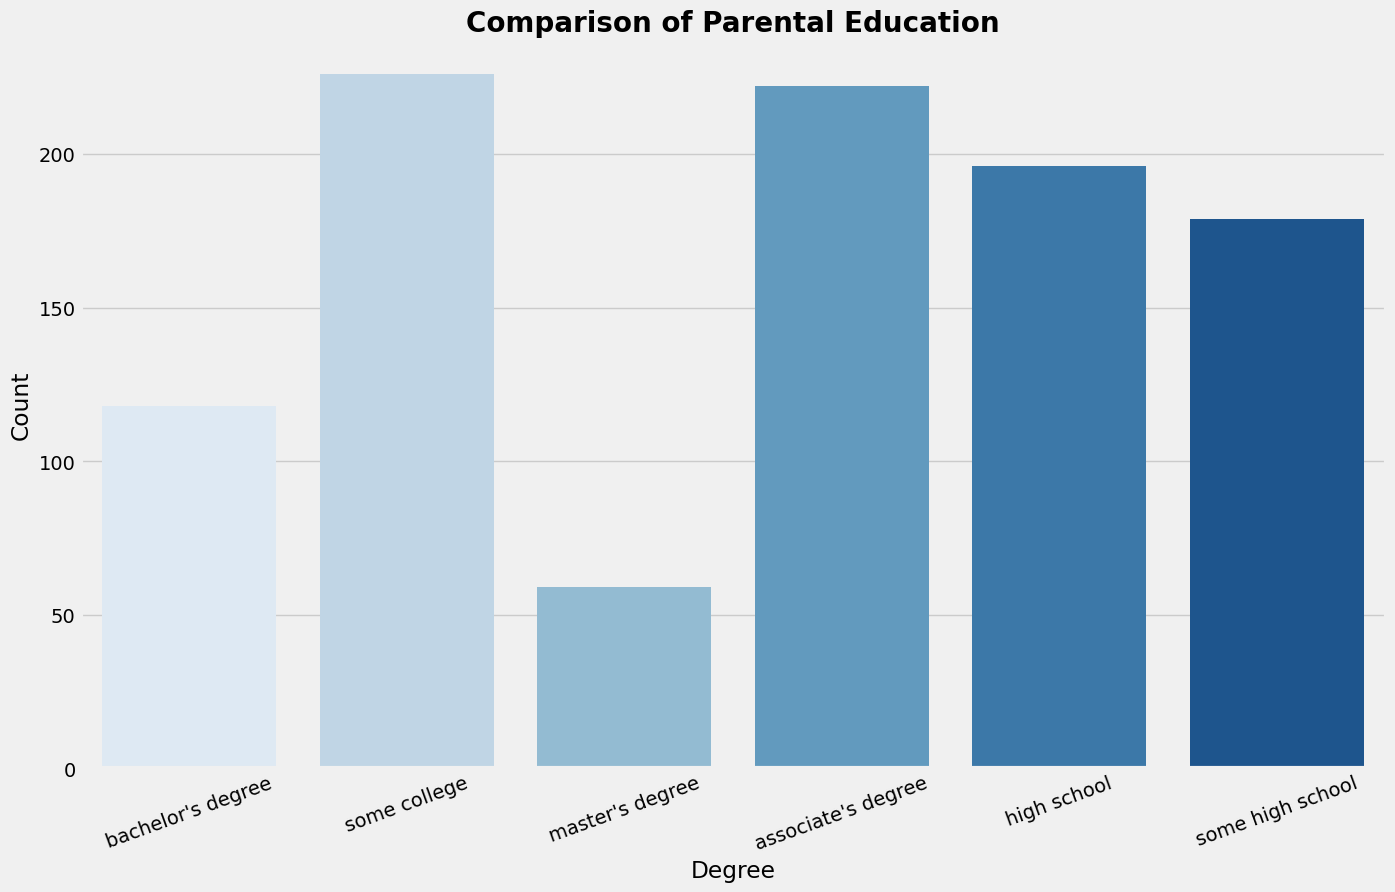

In [36]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')

sns.countplot(
    x='parental_level_of_education',
    data=df,
    palette='Blues'
)

plt.title('Comparison of Parental Education', fontsize=20, fontweight='bold')
plt.xlabel('Degree')
plt.ylabel('Count')
plt.xticks(rotation=20)

plt.show()

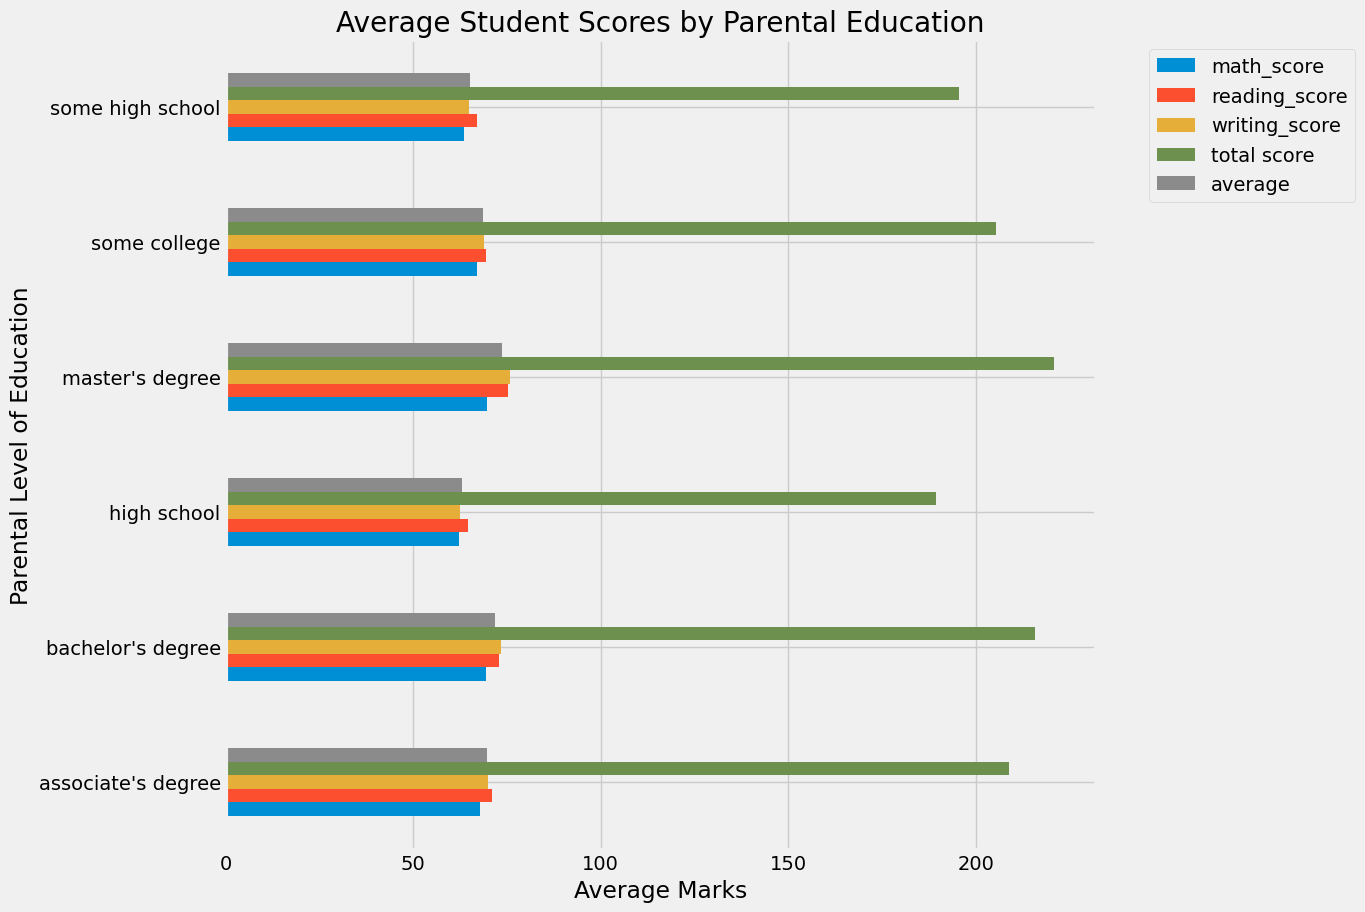

In [37]:
df.groupby('parental_level_of_education').mean(numeric_only=True).plot(
    kind='barh',
    figsize=(10, 10)
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Average Marks")
plt.ylabel("Parental Level of Education")
plt.title("Average Student Scores by Parental Education")

plt.show()

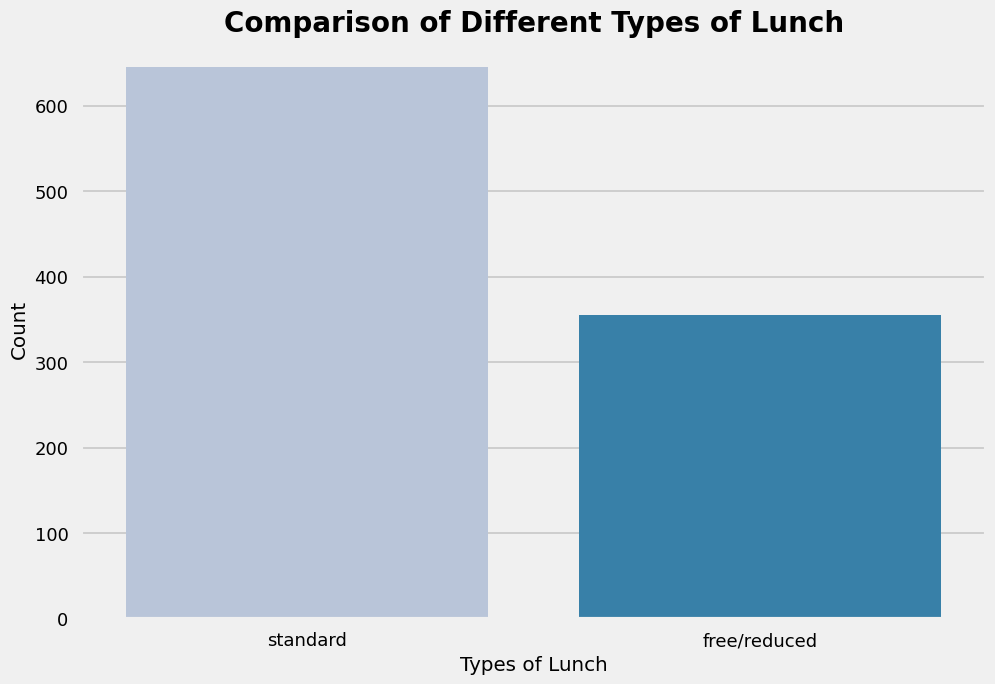

In [39]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-v0_8-talk')   # or use 'ggplot' if this gives an error

sns.countplot(
    x='lunch',
    data=df,
    palette='PuBu'
)

plt.title('Comparison of Different Types of Lunch', fontsize=20, fontweight='bold')
plt.xlabel('Types of Lunch')
plt.ylabel('Count')

plt.show()

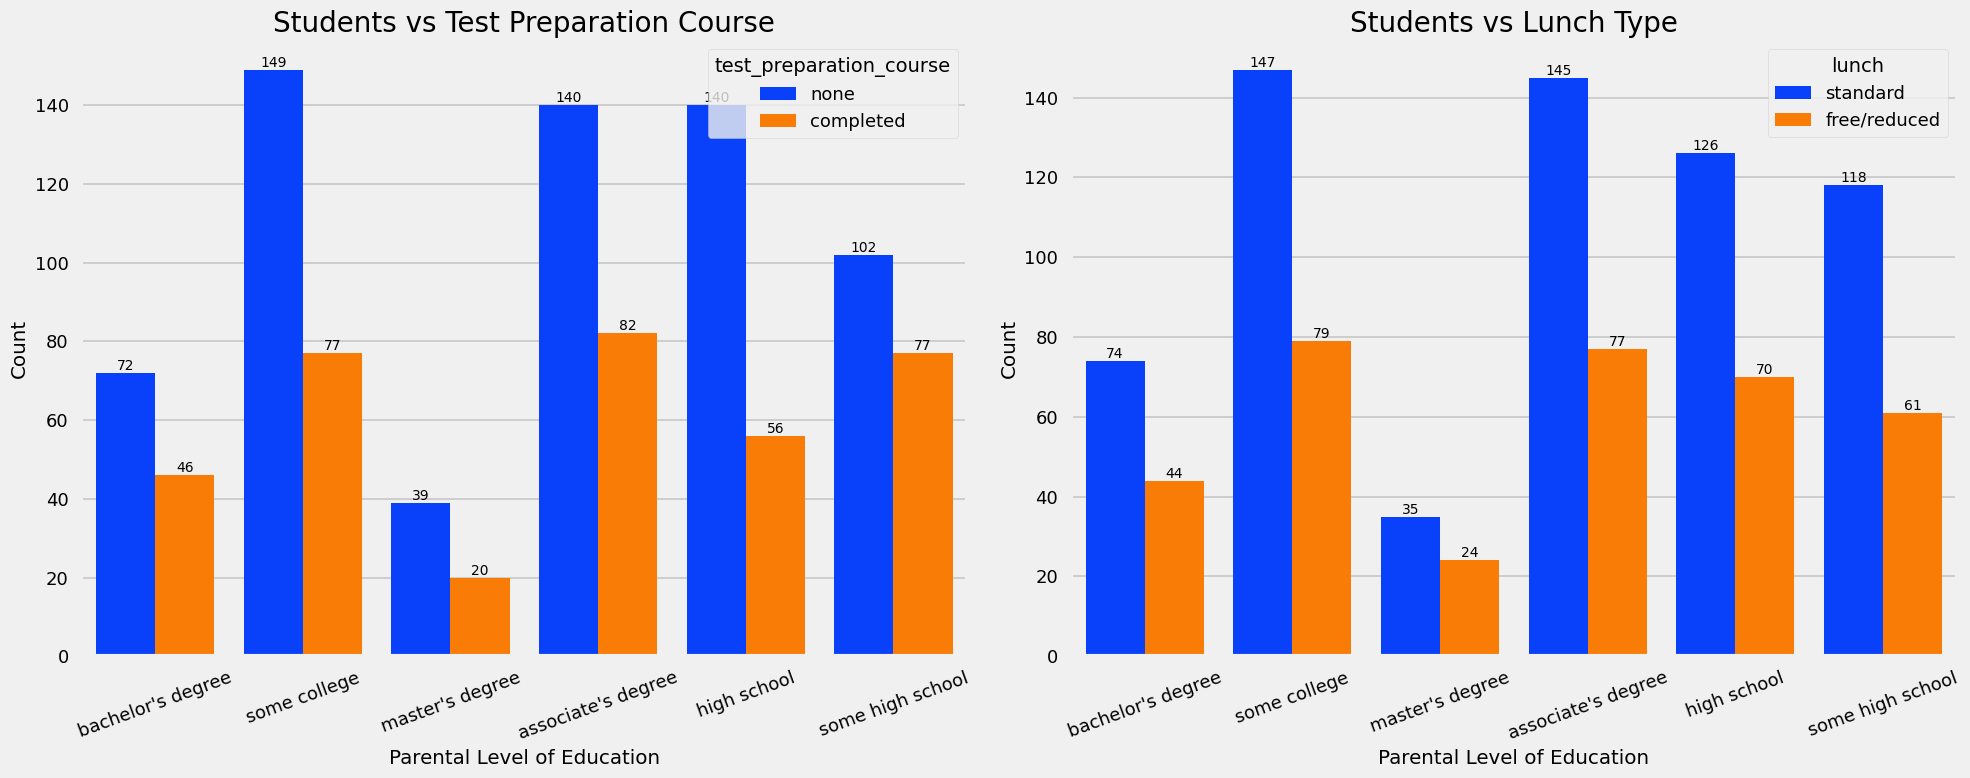

In [40]:
f, ax = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Parental Education vs Test Preparation Course
sns.countplot(
    x='parental_level_of_education',
    data=df,
    hue='test_preparation_course',
    palette='bright',
    saturation=0.95,
    ax=ax[0]
)

ax[0].set_title('Students vs Test Preparation Course', color='black', fontsize=20)
ax[0].set_xlabel('Parental Level of Education')
ax[0].set_ylabel('Count')
ax[0].tick_params(axis='x', rotation=20)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', fontsize=10)

# Plot 2: Parental Education vs Lunch
sns.countplot(
    x='parental_level_of_education',
    data=df,
    hue='lunch',
    palette='bright',
    saturation=0.95,
    ax=ax[1]
)

ax[1].set_title('Students vs Lunch Type', color='black', fontsize=20)
ax[1].set_xlabel('Parental Level of Education')
ax[1].set_ylabel('Count')
ax[1].tick_params(axis='x', rotation=20)

for container in ax[1].containers:
    ax[1].bar_label(container, color='black', fontsize=10)

plt.tight_layout()
plt.show()

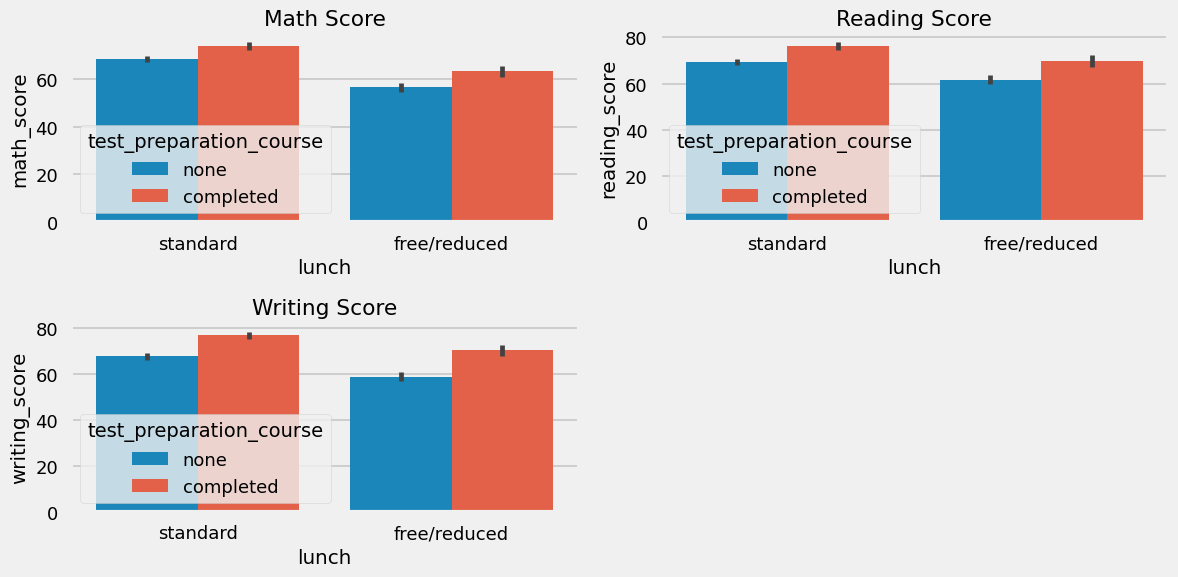

In [41]:
plt.figure(figsize=(12, 6))

# Math Score
plt.subplot(2, 2, 1)
sns.barplot(
    x='lunch',
    y='math_score',
    hue='test_preparation_course',
    data=df
)
plt.title('Math Score')

# Reading Score
plt.subplot(2, 2, 2)
sns.barplot(
    x='lunch',
    y='reading_score',
    hue='test_preparation_course',
    data=df
)
plt.title('Reading Score')

# Writing Score
plt.subplot(2, 2, 3)
sns.barplot(
    x='lunch',
    y='writing_score',
    hue='test_preparation_course',
    data=df
)
plt.title('Writing Score')

plt.tight_layout()
plt.show()

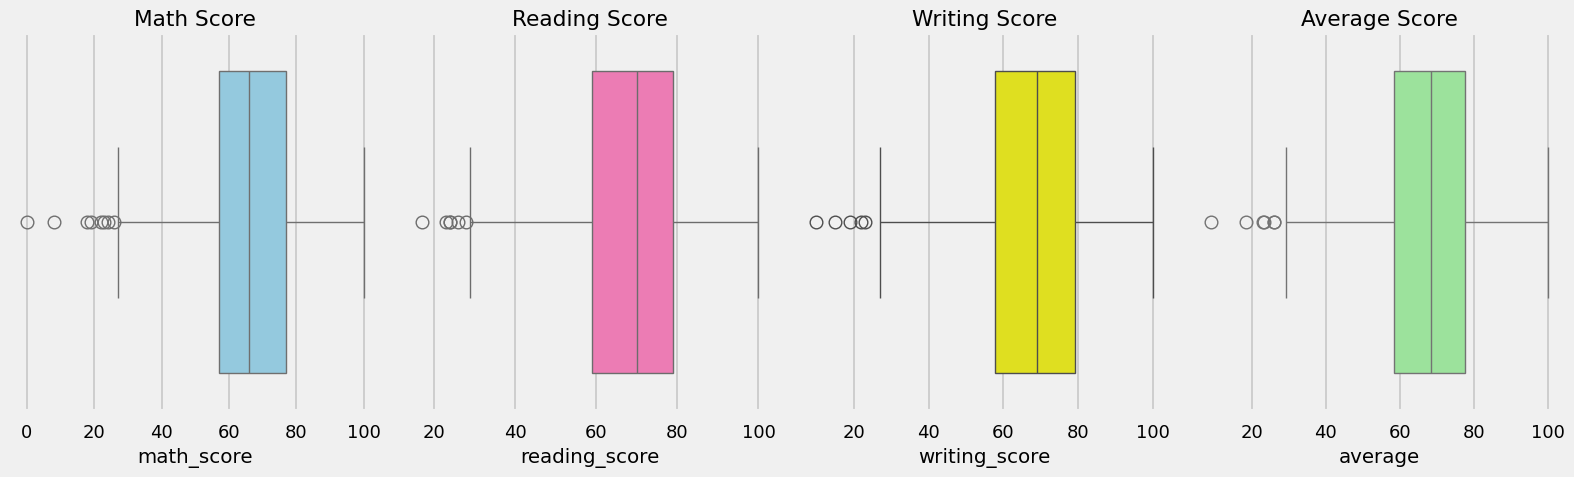

In [43]:
plt.figure(figsize=(16, 5))

# Math Score
plt.subplot(1, 4, 1)
sns.boxplot(x='math_score', data=df, color='skyblue')
plt.title('Math Score')

# Reading Score
plt.subplot(1, 4, 2)
sns.boxplot(x='reading_score', data=df, color='hotpink')
plt.title('Reading Score')

# Writing Score
plt.subplot(1, 4, 3)
sns.boxplot(x='writing_score', data=df, color='yellow')
plt.title('Writing Score')

# Average Score
plt.subplot(1, 4, 4)
sns.boxplot(x='average', data=df, color='lightgreen')
plt.title('Average Score')

plt.tight_layout()
plt.show()

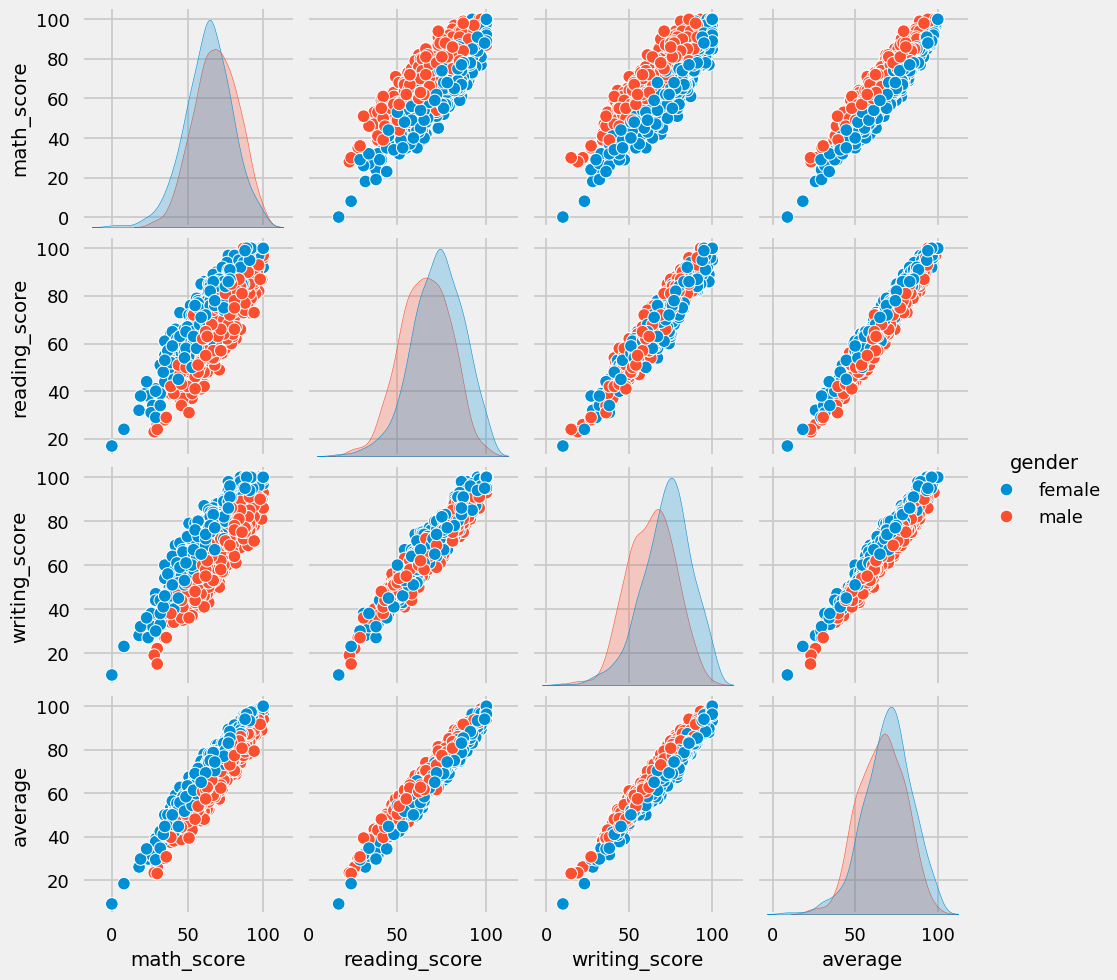

In [44]:
sns.pairplot(
    df[
        ['math_score', 'reading_score', 'writing_score', 'average', 'gender']
    ],
    hue='gender'
)

plt.show()